In [61]:
import glob
import os
import tarfile
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.utils import get_file

In [2]:
DATASET_URL = 'https://datashare.is.ed.ac.uk/bitstream/handle/10283/3192/CINIC-10.tar.gz?sequence=4&isAllowed=y'
DATA_NAME = 'cinic10'
FILE_EXTENSION = 'tar.gz'
FILE_NAME = '.'.join([DATA_NAME, FILE_EXTENSION])

In [3]:
# get_file(): Downloads a file from a URL if it not already in the cache.
# By default, the file at the url origin is downloaded to the cache_dir ~/.keras, placed in the cache_subdir datasets, and given the filename fname. The final location of a file example. txt would therefore be ~/.keras/ datasets/ example. txt.
# it returns the location of the downloaded file
downloaded_file_location = get_file(origin=DATASET_URL, fname=FILE_NAME, extract=False)



687544992/687544992 [==============================] - 618s 1us/step


In [18]:
downloaded_file_location

'C:\\Users\\user\\.keras\\datasets\\cinic10.tar.gz'

In [19]:
os.path.sep

'\\'

In [20]:
data_directory, _= downloaded_file_location.rsplit(sep=os.path.sep,maxsplit=1)
data_directory

'C:\\Users\\user\\.keras\\datasets'

In [21]:
# so we tried here to get the path of the downloaded cinic10.tar.gz file and then create a name for the folder that will be created during the extraction in the same path
data_directory = os.path.sep.join([data_directory, DATA_NAME])
data_directory

'C:\\Users\\user\\.keras\\datasets\\cinic10'

In [71]:
# creating a tar object that opens the download file and ready to be extracted using the extractall(data_directory)

tar = tarfile.open(downloaded_file_location)

In [23]:
if not os.path.exists(data_directory):
    # this extractall will find that cinic10 folder doesn't exist, so it will create it on the fly
    tar.extractall(data_directory)





In [24]:
# we will create a regex pattern to search with using the glob() from glob library and search for all files that matches the provided extension
print(f'Data downloaded to {data_directory}')
# '*/*/*.png', this way will allow nested searching for png files in the whole folder and its subfolders.
data_pattern = os.path.sep.join([data_directory, '*/*/*.png'])

Data downloaded to C:\Users\user\.keras\datasets\cinic10


In [72]:
data_pattern

'C:\\Users\\user\\.keras\\datasets\\cinic10\\*/*/*.png'

In [25]:
# glob(): will return a list of paths that matches the pattern provided
image_paths = list(glob.glob(data_pattern))
print(f'Sample image path: {image_paths[0]}')

Sample image path: C:\Users\user\.keras\datasets\cinic10\test\airplane\cifar10-test-10.png


In [39]:
# Loading the image into PIL format (Python imaging library)  that adds support for opening, manipulating, and saving many different image file formats
sample_image = load_img(image_paths[0])

'RGB'

In [41]:
print(f'Image format: {sample_image.format}')
print(f'Image type: {type(sample_image)}')
print(f'Image mode: {sample_image.mode}')
print(f'Image mode: {sample_image.size}')

Image type: PNG
Image type: <class 'PIL.PngImagePlugin.PngImageFile'>
Image format: RGB
Image mode: (32, 32)


In [42]:
# converting the image format file of pixel values into nd array so that it can be processed by models
sample_image_array = img_to_array(sample_image)
print(f'Image array shape: {sample_image_array.shape}')


Image array shape: (32, 32, 3)


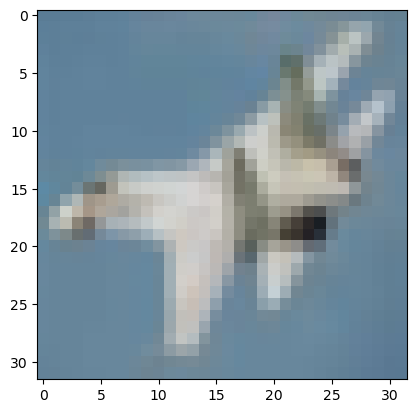

In [44]:
# normalizing the pixel range of values
plt.imshow(sample_image_array / 255.0)

In [46]:
# showing Data Augmentation for images using the image data generator that allows creating a list of different image augmentations or transformations that will be applied to all iages in batches for memory usage efficiency by using python iterator object.
scale_factor = 1.0 / 255.0
image_generator = ImageDataGenerator(horizontal_flip=True, rescale=scale_factor)
# The iterator object will load a number of images each time = batch size and apply the transformations defined in image_generator object and then load the next batch of images and so on. this way will ensure that memory usage will be more efficient and handled during runtime.
iterator = (image_generator
            .flow_from_directory(directory=data_directory,
                                 batch_size=10))


Found 270000 images belonging to 3 classes.


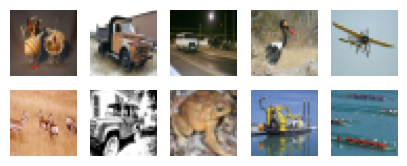

In [59]:
# visualizing the random batch that is 10 images in a grid of 5*5 using matplotlib.  
for batch, _ in iterator:
    plt.figure(figsize=(5, 5))
    for index, image in enumerate(batch, start=1):
        ax = plt.subplot(5, 5, index)
        plt.imshow(image)
        plt.axis('off')

    plt.show()
    break

In [64]:
image_dataset = tf.data.Dataset.list_files(data_pattern)
for file_path in image_dataset.take(1):
    sample_path = file_path.numpy()
    print(f'Sample image path: {sample_path}')

Sample image path: b'C:\\Users\\user\\.keras\\datasets\\cinic10\\train\\deer\\n02432511_149.png'


In [65]:
# Load a single image
sample_image = tf.io.read_file(sample_path)
print(f'Image type: {type(sample_image)}')


Image type: <class 'tensorflow.python.framework.ops.EagerTensor'>


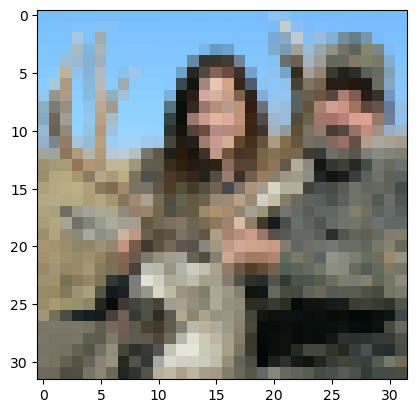

In [66]:
sample_image = tf.image.decode_png(sample_image, channels=3)

plt.imshow(sample_image.numpy() / 255.0)

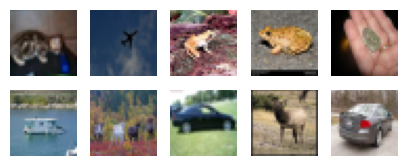

In [67]:
# batch of images.
plt.figure(figsize=(5, 5))
for index, image_path in enumerate(image_dataset.take(10), start=1):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.convert_image_dtype(image, np.float32)

    ax = plt.subplot(5, 5, index)
    plt.imshow(image)
    plt.axis('off')

plt.show()
plt.close()